# PROBLEM STATEMENT

---
---
Predict student performance based on study habits, attendance, and participation.
Also evaluate performance.

In [3]:
# ============================================
# IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [4]:
# mount drive to connect datasee
# ============================================
# LOAD DATASET
# ============================================
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


In [9]:
# ============================================
# FEATURE SELECTION (INPUT & OUTPUT)
# ============================================

X = df[['study_hours_per_week', 'attendance_percentage', 'assignments_submitted']]
y = df['final_exam_score']

In [17]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [18]:
# ============================================
# MODEL TRAINING (LINEAR REGRESSION)
# ============================================
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
# ============================================
# MODEL PREDICTION
# ============================================
y_pred = model.predict(X_test)

In [20]:
# ============================================
# MODEL EVALUATION (MAE)
# ============================================
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 8.017724727128911


In [21]:
# ============================================
# TEST WITH NEW DATA
# ============================================
new_data = [[10, 85, 8]]  # study_hours, attendance, assignments
prediction = model.predict(new_data)

print("Predicted Score:", prediction[0])

Predicted Score: 81.54311585414484


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


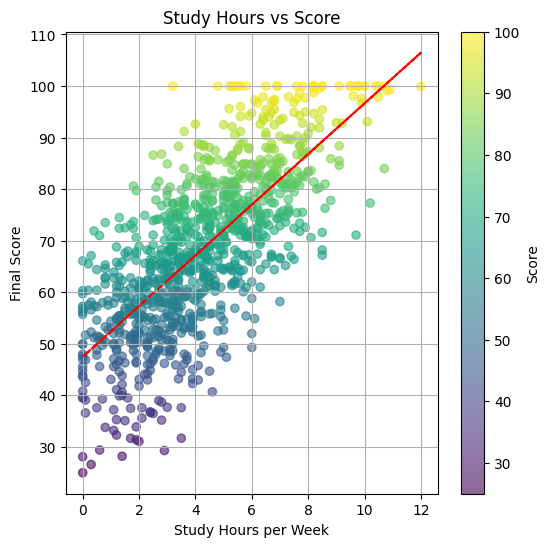

In [34]:
# ============================================
# VISUALIZATION: STUDY HOURS VS SCORE
# ============================================
plt.figure(figsize=(6,6))

plt.scatter(df['study_hours_per_week'], df['final_exam_score'],
            c=df['final_exam_score'], cmap='viridis', alpha=0.6)

# best fit line
z = np.polyfit(df['study_hours_per_week'], df['final_exam_score'], 1)
p = np.poly1d(z)
plt.plot(df['study_hours_per_week'], p(df['study_hours_per_week']), 'r--')

plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.title("Study Hours vs Score")
plt.colorbar(label="Score")
plt.grid(True)

plt.show()

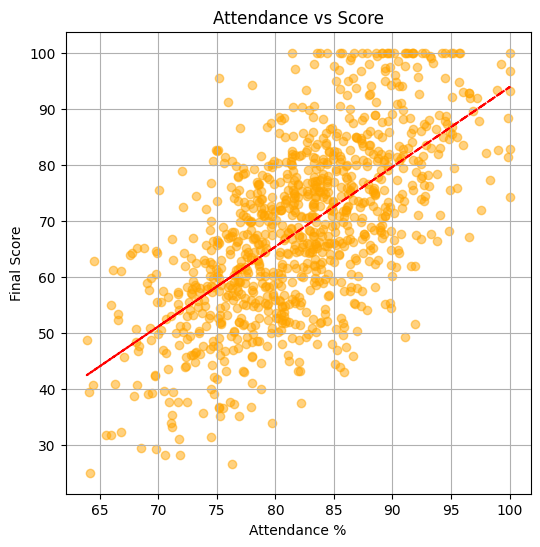

In [35]:
# ============================================
# VISUALIZATION: ATTENDANCE VS SCORE
# ============================================
plt.figure(figsize=(6,6))

plt.scatter(df['attendance_percentage'], df['final_exam_score'],
            c='orange', alpha=0.5)

z = np.polyfit(df['attendance_percentage'], df['final_exam_score'], 1)
p = np.poly1d(z)
plt.plot(df['attendance_percentage'], p(df['attendance_percentage']), 'r--')

plt.xlabel("Attendance %")
plt.ylabel("Final Score")
plt.title("Attendance vs Score")
plt.grid(True)

plt.show()

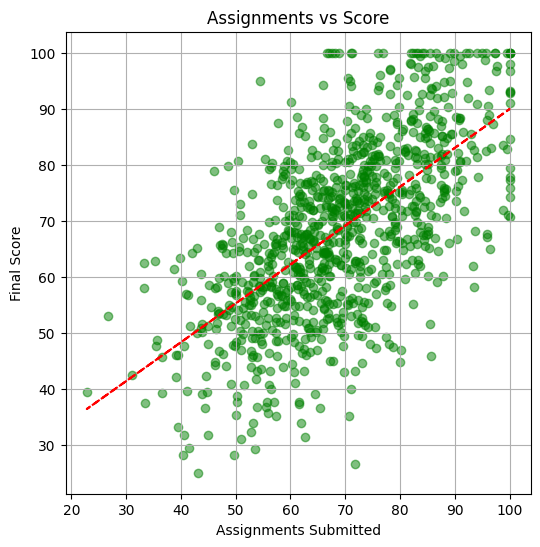

In [36]:
# ============================================
# VISUALIZATION: ASSIGNMENTS VS SCORE
# ============================================
plt.figure(figsize=(6,6))

plt.scatter(df['assignments_submitted'], df['final_exam_score'],
            c='green', alpha=0.5)

z = np.polyfit(df['assignments_submitted'], df['final_exam_score'], 1)
p = np.poly1d(z)
plt.plot(df['assignments_submitted'], p(df['assignments_submitted']), 'r--')

plt.xlabel("Assignments Submitted")
plt.ylabel("Final Score")
plt.title("Assignments vs Score")
plt.grid(True)

plt.show()

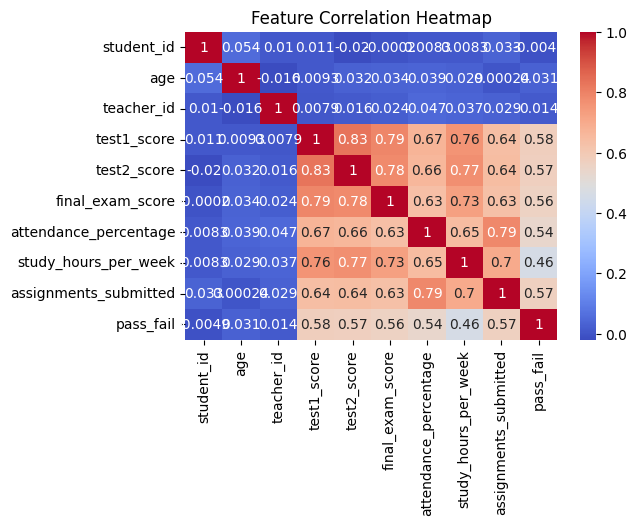

In [37]:
# ============================================
# CORRELATION HEATMAP
# ============================================
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

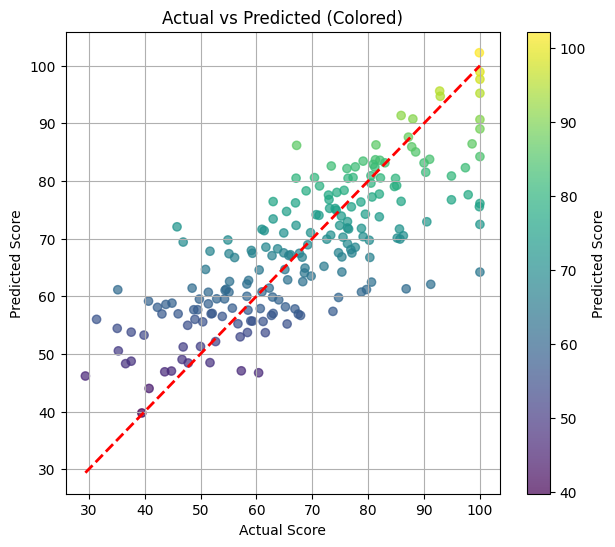

In [39]:
# ============================================
# VISUALIZATION: ACTUAL VS PREDICTED (COLORED)
# ============================================

plt.figure(figsize=(7,6))

# colored scatter (color depends on predicted value)
scatter = plt.scatter(
    y_test,
    y_pred,
    c=y_pred,
    cmap='viridis',   # color theme
    alpha=0.7
)

# color bar (very important for understanding)
plt.colorbar(scatter, label="Predicted Score")

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--', linewidth=2
)

# labels and title
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted (Colored)")

plt.grid(True)

plt.show()

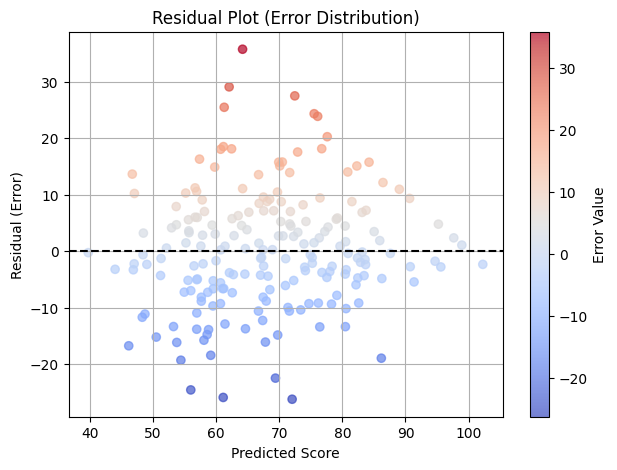

In [40]:
# ============================================
# VISUALIZATION: RESIDUAL ERROR
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals, c=residuals, cmap='coolwarm', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel("Predicted Score")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot (Error Distribution)")

plt.colorbar(label="Error Value")

plt.grid(True)

plt.show()

In [41]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared}")

R-squared: 0.6154372959171093


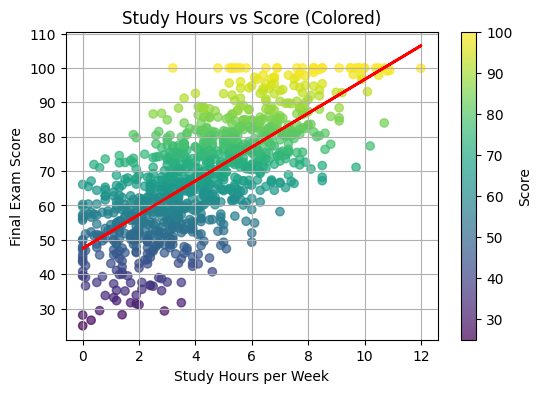

In [29]:
import matplotlib.pyplot as plt
import numpy as np

x = df['study_hours_per_week']
y = df['final_exam_score']

plt.figure(figsize=(6,4))

# scatter with color based on score
plt.scatter(x, y, c=y, cmap='viridis', alpha=0.7)

# add color bar
plt.colorbar(label='Score')

# trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color='red', linewidth=2)

plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")
plt.title("Study Hours vs Score (Colored)")
plt.grid(True)

plt.show()
